# NBA fantasy stacking lab

This notebook mirrors the CLI pipeline in `nba_fantasy_predictor/` from cached raw pulls (no surprise API traffic while reviewing cells — flip `FORCE_REFRESH=True` whenever you deliberately want fresh stats).

## Why stacking?

Tree ensembles (gradient boosting / random forests) memorize smooth non-linearities in minute / usage patterns, whereas ridge regression excels at exploiting linear signal in rolling shooting splits. **[Stacking]** keeps each specialist focused on patterns it expresses well, while a convex **Ridge meta-learner** learns how to reconcile their heterogeneous errors using **held-out validation predictions**. Training the meta-learner on in-fold training forecasts would inflate scores because bases would leak target information through overfit predictions — strictly out-of-sample validation columns keep the stacking layer honest.

## Why date splits instead of random shuffles?

**Chronological partitions** emulate real deployment — we train on historic games before the validation window releases, then certify on the withheld season tail. Random folding would splice future games next to yesterday's row, artificially boosting accuracy and collapsing when you finally predict *next* game's fantasy total.

## Why lagged rolling statistics?

**`shift(1)` before rolling** guarantees every engineered column only reads boxscore fields from games that concluded before tonight's matchup. Matching that discipline with chronological splits aligns offline metrics with production drift when roles, rotations, or trade-deadline context evolve.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np

ROOT = pathlib.Path.cwd()
predictor_pkg = ROOT / "nba_fantasy_predictor"
nested_config = predictor_pkg / "config.py"
local_config = ROOT / "config.py"
import os
import sys

if local_config.exists():
    predictor_dir = ROOT
elif nested_config.exists():
    predictor_dir = predictor_pkg
else:
    raise FileNotFoundError("Unable to locate nba_fantasy_predictor package — run notebook from workspace root or package folder.")

os.chdir(predictor_dir)
if str(predictor_dir) not in sys.path:
    sys.path.insert(0, str(predictor_dir))

warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
from config import SEASONS, TEST_START

from data_fetcher import fetch_player_game_logs

FORCE_REFRESH = False

raw_logs = fetch_player_game_logs(force_refresh=FORCE_REFRESH)
raw_logs.tail()

,PLAYER_ID,PLAYER_NAME,GAME_DATE,MATCHUP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,NBA_FANTASY_PTS,SEASON
6056,1629027,Trae Young,2026-03-05T00:00:00,WAS vs. UTA,19.033333,12,2,6,2,0,3,0.444,0.2,0.50,4,26.4,2025-26
6057,1629027,Trae Young,2026-03-08T00:00:00,WAS @ NOP,17.733333,17,4,8,0,0,4,0.667,0.6,0.75,0,29.8,2025-26
6058,1629027,Trae Young,2026-03-12T00:00:00,WAS @ ORL,21.233333,15,3,6,0,0,2,0.714,0.5,1.00,-13,25.6,2025-26
6059,1629027,Trae Young,2026-03-14T00:00:00,WAS @ BOS,24.466667,11,4,6,0,0,1,0.500,0.0,0.50,-23,23.8,2025-26
6060,1629027,Trae Young,2026-03-16T00:00:00,WAS vs. GSW,21.183333,21,2,5,1,1,3,0.700,0.6,0.80,3,33.9,2025-26


In [3]:
from dataset import (
    OpponentEncoder,
    attach_opponent_codes,
    derive_feature_columns,
    frames_to_xy,
    split_by_date,
)
from evaluate import (
    compare_models,
    compute_metrics,
    mean_prediction_bias,
    plot_predictions,
    plot_residuals,
)
from features import engineer_features
from inference import predict_next_game
from train import main as train_models


feature_df, _ = engineer_features(raw_logs)
train_df, val_df, test_df = split_by_date(feature_df)
encoder = OpponentEncoder().fit(train_df["opponent"].astype(str))
train_df = attach_opponent_codes(train_df, encoder)
val_df = attach_opponent_codes(val_df, encoder)
test_df = attach_opponent_codes(test_df, encoder)
feature_cols = derive_feature_columns(train_df)
(x_tr, y_tr), (x_val, y_val), (x_te, y_te) = frames_to_xy(train_df, val_df, test_df, feature_cols)

In [4]:
# Train (uses cached CSV unless you edit train.py argparse flow)
train_models(force_refresh=FORCE_REFRESH)

import joblib
from pathlib import Path

from config import MODELS_DIR, STACKED_ARTIFACT_FILENAME


bundle_path = Path(MODELS_DIR) / STACKED_ARTIFACT_FILENAME
bundle = joblib.load(bundle_path)
ensemble = bundle["ensemble"]

[0]	validation_0-rmse:8.87577	validation_1-rmse:9.45985
[1]	validation_0-rmse:8.71194	validation_1-rmse:9.27502
[2]	validation_0-rmse:8.56111	validation_1-rmse:9.11959
[3]	validation_0-rmse:8.41216	validation_1-rmse:8.95116
[4]	validation_0-rmse:8.27939	validation_1-rmse:8.81291
[5]	validation_0-rmse:8.20091	validation_1-rmse:8.70644
[6]	validation_0-rmse:8.06324	validation_1-rmse:8.56069
[7]	validation_0-rmse:7.93809	validation_1-rmse:8.42287
[8]	validation_0-rmse:7.82004	validation_1-rmse:8.29101
[9]	validation_0-rmse:7.70500	validation_1-rmse:8.17214
[10]	validation_0-rmse:7.60508	validation_1-rmse:8.07542
[11]	validation_0-rmse:7.52948	validation_1-rmse:7.98712
[12]	validation_0-rmse:7.45515	validation_1-rmse:7.91148
[13]	validation_0-rmse:7.38184	validation_1-rmse:7.83610
[14]	validation_0-rmse:7.29231	validation_1-rmse:7.75008
[15]	validation_0-rmse:7.21418	validation_1-rmse:7.66754
[16]	validation_0-rmse:7.13017	validation_1-rmse:7.58665
[17]	validation_0-rmse:7.05391	validation

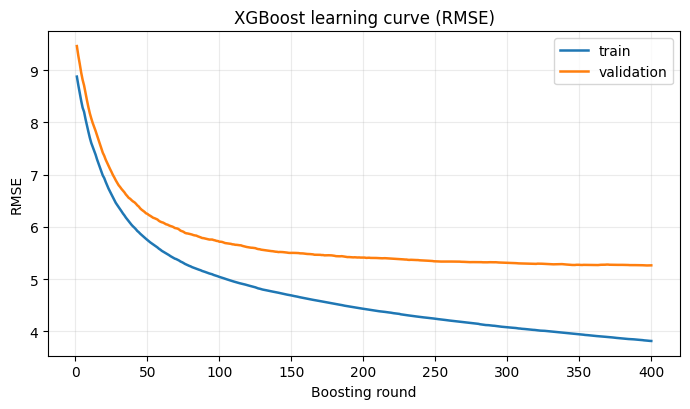

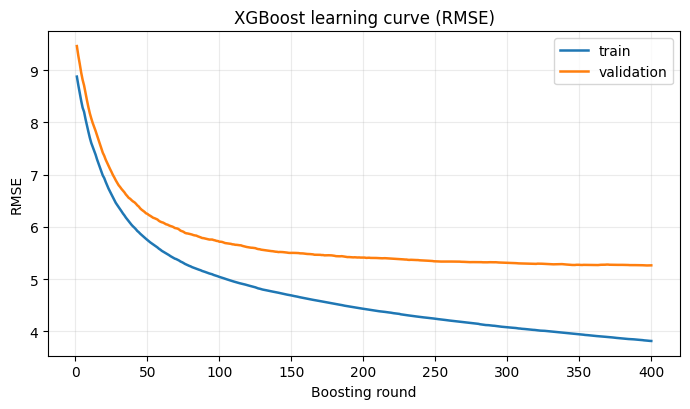

In [5]:
# Train vs validation RMSE each boosting round (from XGBoost eval history).
# Diverging curves ⇒ variance/overfitting on train; parallel ⇒ mostly bias / capacity limits.

from evaluate import plot_xgboost_learning_curves

fig_lc = plot_xgboost_learning_curves(bundle)
fig_lc

xgboost         MAE=4.039 RMSE=5.135 R2=0.610  bias(pred-actual)=+0.165


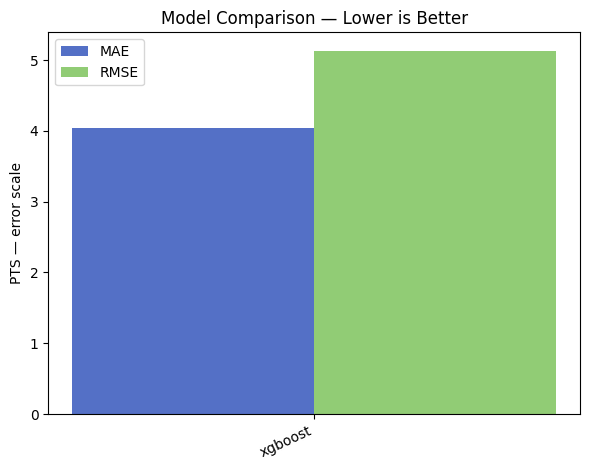

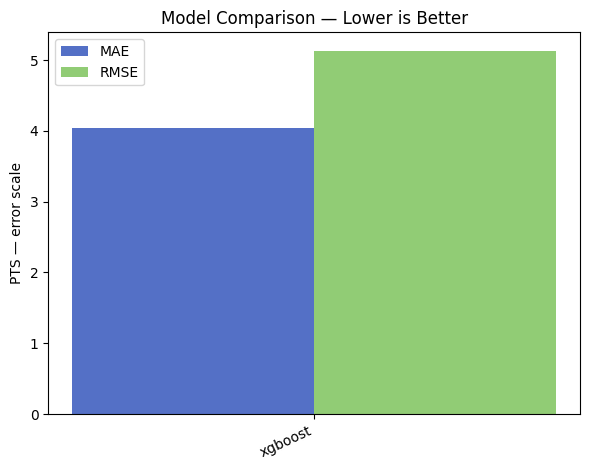

In [6]:
results = {}


def benchmark(name: str, y_true: np.ndarray, preds: np.ndarray) -> dict:
    scores = compute_metrics(y_true, preds)
    bias = mean_prediction_bias(y_true, preds)
    print(
        f"{name:15s} MAE={scores['mae']:.3f} RMSE={scores['rmse']:.3f} "
        f"R2={scores['r2']:.3f}  bias(pred-actual)={bias:+.3f}"
    )
    return scores


if getattr(ensemble, "base_learners", None):
    for lbl, learner in ensemble.base_learners:
        results[lbl] = (y_te, learner.predict(x_te))
    head_preds = ensemble.predict(x_te)
    results["stacked_ridge"] = (y_te, head_preds)
else:
    xgb_preds = ensemble.predict(x_te)
    results["xgboost"] = (y_te, xgb_preds)

best_name = None
best_val = np.inf
for name, (truth, preds) in results.items():
    mae_te = benchmark(name, truth, preds)
    if mae_te["mae"] < best_val:
        best_val = mae_te["mae"]
        best_name = name


fig_cmp = compare_models(results)
fig_cmp

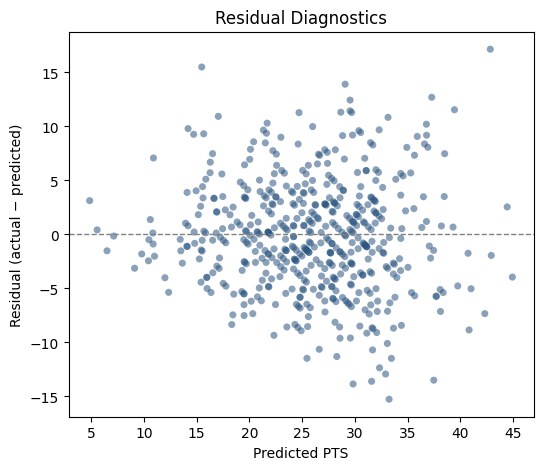

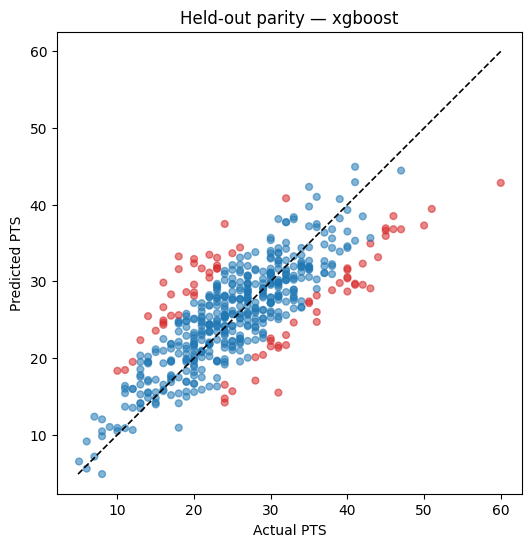

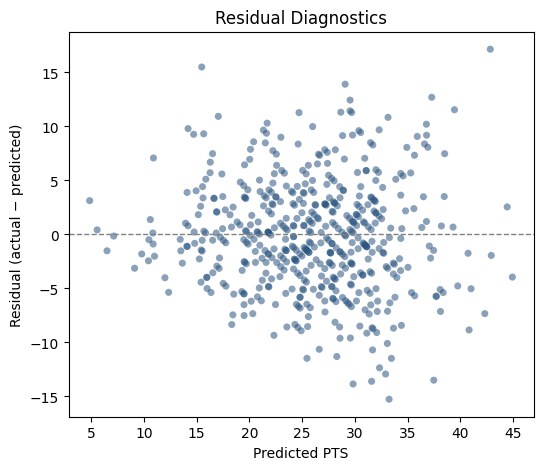

In [7]:
truth_best, preds_best = results[best_name]
fig_diag = plot_predictions(truth_best, preds_best, title=f"Held-out parity — {best_name}")
fig_diag


fig_res = plot_residuals(truth_best, preds_best)
fig_res


## Live inference snippets

Each invocation issues fresh **`nba_api` PlayerGameLogs** calls (paced with `sleep(1)` in `data_fetcher.py`), so stagger notebook runs sparingly unless you widen the pacing constant.

In [ ]:
# Live inference: PLAYER_ID matches NBA.com player URLs → https://www.nba.com/player/<PLAYER_ID>/...
# Rosters: Lakers https://www.nba.com/lakers/roster | Thunder https://www.nba.com/thunder/roster
#          Pistons https://www.nba.com/pistons/roster | Cavaliers https://www.nba.com/cavaliers/roster
# Rows pulled from NBA Stats CommonTeamRoster (season 2025-26), aligned with those pages.
# One Stats-backed fetch per player (~1s pacing each).
demo_ids = [
    # Detroit Pistons (2025-26 roster)
    (1631105, "Jalen Duren"),
    (1630595, "Cade Cunningham"),
    (1642403, "Isaac Jones"),
    (1641842, "Ronald Holland II"),
    (1630194, "Paul Reed"),
    (1627747, "Caris LeVert"),
    (1641709, "Ausar Thompson"),
    (202699, "Tobias Harris"),
    (1631111, "Wendell Moore Jr."),
    (1642404, "Chaz Lanier"),
    (1642450, "Daniss Jenkins"),
    (1631204, "Marcus Sasser"),
    (1628989, "Kevin Huerter"),
    (1630191, "Isaiah Stewart"),
    (1629750, "Javonte Green"),
    (1642449, "Tolu Smith"),
    (1629130, "Duncan Robinson"),
    # Cleveland Cavaliers (2025-26 roster — Stats/NBA.com snapshot)
    (201935, "James Harden"),
    (1629622, "Max Strus"),
    (1628418, "Thomas Bryant"),
    (1630596, "Evan Mobley"),
    (1630241, "Sam Merrill"),
    (203471, "Dennis Schröder"),
    (1641854, "Craig Porter Jr."),
    (1642434, "Riley Minix"),
    (1631165, "Keon Ellis"),
    (1642281, "Jaylon Tyson"),
    (1642400, "Tristan Enaruna"),
    (1626204, "Larry Nance Jr."),
    (1642878, "Tyrese Proctor"),
    (1628386, "Jarrett Allen"),
    (1629731, "Dean Wade"),
    (1630846, "Olivier Sarr"),
    (1641772, "Nae'Qwan Tomlin"),
    (1628378, "Donovan Mitchell"),
]

CURRENT_SEASON = SEASONS[-1]

bundle = bundle  # Defined after training cell


for pid, pname in demo_ids:
    print(f"\n=== Inference for {pname} (PID={pid}) ===")
    try:
        _ = predict_next_game(pid, CURRENT_SEASON, bundle=bundle)
    except RuntimeError as err:
        print(f"⚠ inference skipped ({err})")


---

`TEST_START={TEST_START}` demarcates the cold evaluation window seeded from `config.py`, keeping every chart above strictly forward-looking versus the training corpus.